# Linguistic Boundaries Between Human and Machine Writing

### A Comparative Stylometric Analysis of Reuters C50 and HC3

This notebook is the cleaned, reproducible version of the original course experiment.

The project studies whether individual human authors, generic human responses, and ChatGPT-generated responses exhibit distinguishable linguistic patterns.

The final classification setting contains up to **52 classes**:

- 50 Reuters C50 journalists
- Human
- ChatGPT

The workflow combines:

1. dataset preparation,
2. class balancing,
3. stylometric feature extraction,
4. PCA-based visualization,
5. DistilBERT fine-tuning with class-weighted loss,
6. multi-class evaluation,
7. Human-vs-ChatGPT confidence analysis,
8. inference on unseen text.

> **Important:** The original notebook loads the `C50train` portion of Reuters C50 and then creates its own train/validation/test split after combining it with HC3. This cleaned notebook preserves that experimental design rather than silently changing it.


## 1. Environment and Imports

Install the dependencies listed in `requirements.txt` before running this notebook.

For spaCy sentence segmentation, install the package normally; this notebook uses a lightweight blank English pipeline with a `sentencizer`, so no separate language-model download is required.


In [1]:
!pip uninstall -y torchvision

In [2]:
from pathlib import Path
import io
import json
import os
import string
import zipfile
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import spacy
import torch

from datasets import Dataset
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

RANDOM_STATE = 42
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 2. Dataset Preparation

### 2.1 Reuters C50

The Reuters C50 corpus is downloaded from the UCI Machine Learning Repository.

The original project code uses the `C50train` directory as the Reuters source. Each journalist name becomes an `author` label.


In [3]:
REUTERS_URL = "https://archive.ics.uci.edu/static/public/217/reuter+50+50.zip"
REUTERS_DIR = Path("data/reuters")

REUTERS_DIR.mkdir(parents=True, exist_ok=True)

response = requests.get(REUTERS_URL, timeout=60)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
    archive.extractall(REUTERS_DIR)

reuters_root = REUTERS_DIR / "C50train"

data_list = []

for author_folder in sorted(reuters_root.iterdir()):
    if not author_folder.is_dir():
        continue

    for text_file in sorted(author_folder.iterdir()):
        if text_file.is_file():
            text = text_file.read_text(encoding="latin-1")
            data_list.append({
                "author": author_folder.name,
                "text": text,
            })

df_reuters = pd.DataFrame(data_list)

print("Reuters shape:", df_reuters.shape)
print("Reuters authors:", df_reuters["author"].nunique())
df_reuters.head()


Reuters shape: (2500, 2)
Reuters authors: 50


,author,text
0,AaronPressman,The Internet may be overflowing with new techn...
1,AaronPressman,The U.S. Postal Service announced Wednesday a ...
2,AaronPressman,Elementary school students with access to the ...
3,AaronPressman,An influential Internet organisation has backe...
4,AaronPressman,An influential Internet organisation has backe...


### 2.2 HC3

Place the HC3 `.jsonl` files under:

```text
data/hc3/
```

The loader below follows the structure used in the original notebook: each JSON line is expected to contain `human_answers` and `chatgpt_answers`.


In [4]:
HC3_GLOB = Path("data/hc3")

hc3_rows = []

for jsonl_file in sorted(HC3_GLOB.glob("*.jsonl")):
    with jsonl_file.open("r", encoding="utf-8") as file:
        for line in file:
            try:
                item = json.loads(line)

                if item.get("human_answers"):
                    hc3_rows.append({
                        "author": "Human",
                        "text": item["human_answers"][0],
                    })

                if item.get("chatgpt_answers"):
                    hc3_rows.append({
                        "author": "ChatGPT",
                        "text": item["chatgpt_answers"][0],
                    })

            except (json.JSONDecodeError, KeyError, IndexError, TypeError):
                continue

df_hc3 = pd.DataFrame(hc3_rows)

if df_hc3.empty:
    raise FileNotFoundError(
        "No HC3 samples were loaded. Put the HC3 .jsonl files in data/hc3/."
    )

print("HC3 shape:", df_hc3.shape)
print(df_hc3["author"].value_counts())


HC3 shape: (44573, 2)
author
Human      22291
ChatGPT    22282
Name: count, dtype: int64


### 2.3 Merge, Clean, and Balance

Reuters and HC3 are merged into a single authorship dataset.

The original experiment suffered from severe majority-class bias because Human and ChatGPT contained far more samples than each Reuters author. To reduce this effect:

- duplicate texts are removed,
- authors with too few samples are excluded,
- Human and ChatGPT are downsampled to at most 500 samples each,
- class-weighted cross-entropy is later used during training.


In [5]:
df_all = pd.concat([df_reuters, df_hc3], ignore_index=True)

# Basic cleaning
df_all = df_all.dropna(subset=["author", "text"]).copy()
df_all["text"] = df_all["text"].astype(str)
df_all = df_all[df_all["text"].str.strip().ne("")].copy()
df_all = df_all.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Keep authors with enough examples
author_counts = df_all["author"].value_counts()
valid_authors = author_counts[author_counts >= 35].index
df_working = df_all[df_all["author"].isin(valid_authors)].copy()

# Downsample majority Human / ChatGPT classes
df_others = df_working[
    ~df_working["author"].isin(["ChatGPT", "Human"])
]

df_chatgpt = df_working[df_working["author"] == "ChatGPT"]
df_human = df_working[df_working["author"] == "Human"]

df_chatgpt_down = df_chatgpt.sample(
    n=min(500, len(df_chatgpt)),
    random_state=RANDOM_STATE,
)

df_human_down = df_human.sample(
    n=min(500, len(df_human)),
    random_state=RANDOM_STATE,
)

df_working = pd.concat(
    [df_others, df_chatgpt_down, df_human_down],
    ignore_index=True,
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Create contiguous class IDs after all filtering/balancing
df_working["author"] = df_working["author"].astype("category")
df_working["label"] = df_working["author"].cat.codes

target_names = df_working["author"].cat.categories.tolist()
num_classes = len(target_names)

print("Final samples:", len(df_working))
print("Number of classes:", num_classes)
print(df_working["author"].value_counts().sort_index())


Final samples: 3500
Number of classes: 52
author
AaronPressman         50
AlanCrosby            50
AlexanderSmith        50
BenjaminKangLim       50
BernardHickey         50
BradDorfman           50
ChatGPT              500
DarrenSchuettler      50
DavidLawder           50
EdnaFernandes         50
EricAuchard           50
FumikoFujisaki        50
GrahamEarnshaw        50
HeatherScoffield      50
Human                500
JanLopatka            50
JaneMacartney         50
JimGilchrist          50
JoWinterbottom        50
JoeOrtiz              50
JohnMastrini          50
JonathanBirt          50
KarlPenhaul           50
KeithWeir             50
KevinDrawbaugh        50
KevinMorrison         50
KirstinRidley         50
KouroshKarimkhany     50
LydiaZajc             50
LynneO'Donnell        50
LynnleyBrowning       50
MarcelMichelson       50
MarkBendeich          50
MartinWolk            50
MatthewBunce          50
MichaelConnor         50
MureDickie            50
NickLouth             50
P

## 3. Dataset Exploration

A quick inspection helps verify that the final data contains the expected author classes and that Human / ChatGPT no longer dominate the dataset as strongly as in the original unbalanced experiment.


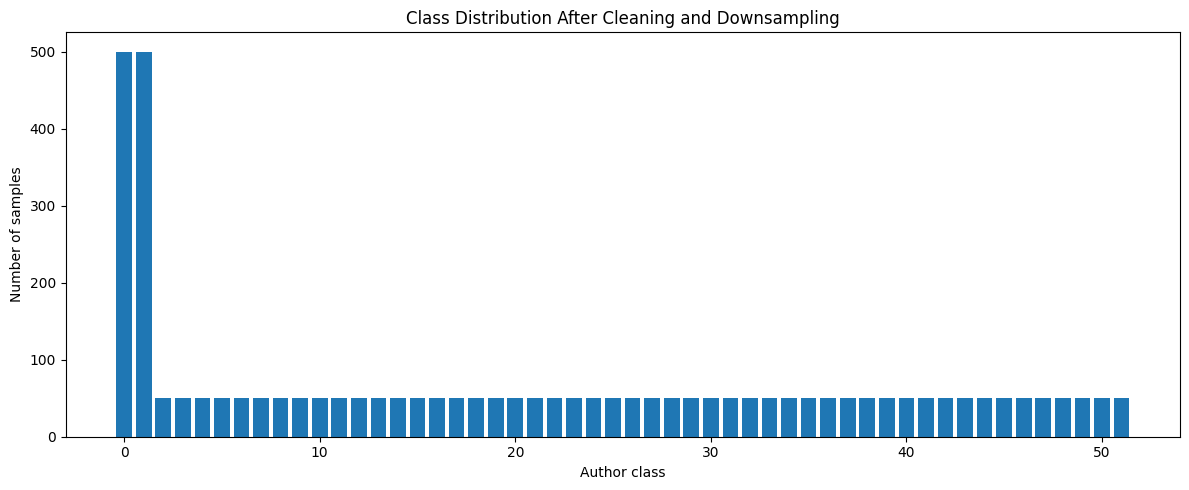

,author,text
1650,FumikoFujisaki,Japan's top banks are touting a plan to lift a...
2456,Human,There are 360 degrees in a circle because the ...
2232,ScottHillis,Jailed Chinese dissident Wang Dan is suffering...
1945,ChatGPT,The SI unit of pressure is the pascal (Pa). Th...
309,ChatGPT,"In the United States, the presidential electio..."


In [6]:
class_counts = df_working["author"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(range(len(class_counts)), class_counts.values)
plt.xlabel("Author class")
plt.ylabel("Number of samples")
plt.title("Class Distribution After Cleaning and Downsampling")
plt.tight_layout()
plt.show()

df_working[["author", "text"]].sample(
    min(5, len(df_working)),
    random_state=RANDOM_STATE,
)


## 4. Stylometric Feature Extraction

The project examines traditional surface-level writing characteristics alongside transformer representations.

The original notebook contained two overlapping feature-extraction implementations. They are consolidated here into one function.

Features:

- word count,
- average sentence length,
- average word length,
- Type-Token Ratio (TTR),
- repetition rate,
- stopword ratio,
- punctuation ratio.


In [7]:
nlp = spacy.blank("en")
nlp.add_pipe("sentencizer")


def extract_stylometric_features(text):
    doc = nlp(text)

    tokens = [
        token.text.lower()
        for token in doc
        if not token.is_space and not token.is_punct
    ]
    sentences = list(doc.sents)

    word_count = len(tokens)
    sentence_count = len(sentences)

    avg_sentence_length = (
        word_count / sentence_count if sentence_count else 0.0
    )

    avg_word_length = (
        np.mean([len(token) for token in tokens])
        if tokens else 0.0
    )

    unique_tokens = len(set(tokens))
    ttr = unique_tokens / word_count if word_count else 0.0

    token_counts = Counter(tokens)
    repeated_types = sum(
        1 for count in token_counts.values() if count > 1
    )
    repetition_rate = (
        repeated_types / unique_tokens if unique_tokens else 0.0
    )

    stopword_count = sum(
        1 for token in tokens if token in ENGLISH_STOP_WORDS
    )
    stopword_ratio = (
        stopword_count / word_count if word_count else 0.0
    )

    punctuation_count = sum(
        1 for char in text if char in string.punctuation
    )
    punctuation_ratio = (
        punctuation_count / len(text) if text else 0.0
    )

    return pd.Series({
        "word_count": word_count,
        "avg_sentence_length": avg_sentence_length,
        "avg_word_length": avg_word_length,
        "ttr": ttr,
        "repetition_rate": repetition_rate,
        "stopword_ratio": stopword_ratio,
        "punctuation_ratio": punctuation_ratio,
    })


stylometric_features = df_working["text"].apply(
    extract_stylometric_features
)

df_features = pd.concat(
    [
        df_working[["author", "label", "text"]].reset_index(drop=True),
        stylometric_features.reset_index(drop=True),
    ],
    axis=1,
)

df_features.head()


,author,label,text,word_count,avg_sentence_length,avg_word_length,ttr,repetition_rate,stopword_ratio,punctuation_ratio
0,MichaelConnor,35,New Corp. Ltd. said Tuesday that its Fox News ...,433.0,33.307692,4.829099,0.454965,0.304569,0.344111,0.024716
1,WilliamKazer,51,China is preparing to tap overseas capital mar...,423.0,24.882353,5.108747,0.513002,0.322581,0.430260,0.018258
2,SimonCowell,46,"Prudential Corp Plc, Britain's biggest life in...",589.0,24.541667,4.925297,0.511036,0.262458,0.412564,0.024287
3,PierreTran,40,France's national audit office on Monday criti...,479.0,21.772727,4.985386,0.480167,0.304348,0.411273,0.019534
4,DarrenSchuettler,7,Anti-government protests swept across Canada's...,667.0,19.057143,4.931034,0.547226,0.273973,0.409295,0.028536


## 5. PCA-Based Stylometric Analysis

PCA is used as an exploratory visualization tool.

The projection does **not** prove that PCA components correspond directly to authorship. It is used to inspect whether the selected stylometric measurements show visible clustering or overlap across author groups.


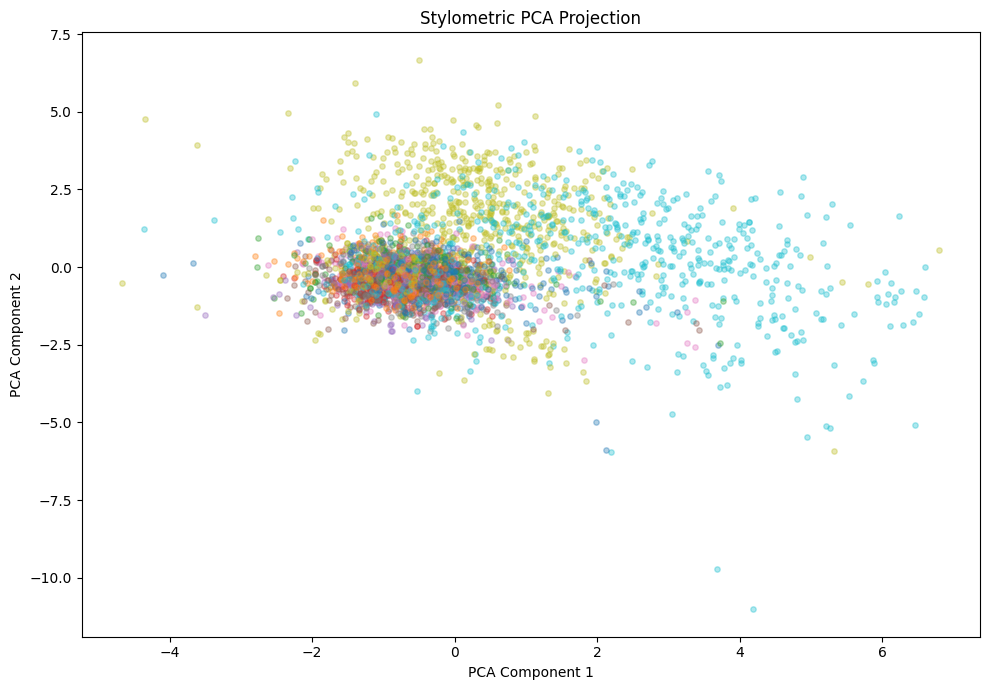

Explained variance ratio: [0.32642097 0.25566714]


In [8]:
PCA_FEATURES = [
    "word_count",
    "avg_sentence_length",
    "avg_word_length",
    "ttr",
    "repetition_rate",
    "stopword_ratio",
    "punctuation_ratio",
]

X_style = df_features[PCA_FEATURES].fillna(0).values
X_scaled = StandardScaler().fit_transform(X_style)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_scaled)

df_features["pca1"] = components[:, 0]
df_features["pca2"] = components[:, 1]

# Plot all points without assigning fixed colors.
plt.figure(figsize=(10, 7))

for author in df_features["author"].unique():
    subset = df_features[df_features["author"] == author]
    plt.scatter(
        subset["pca1"],
        subset["pca2"],
        alpha=0.35,
        s=15,
        label=author,
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Stylometric PCA Projection")

# With 52 classes a full legend is visually crowded, so it is omitted here.
plt.tight_layout()
plt.show()

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_,
)


## 6. DistilBERT Multi-Class Classification

The main predictive model is `distilbert-base-uncased`.

The cleaned experiment uses:

- stratified 70/15/15 train-validation-test split,
- dynamic padding,
- maximum sequence length of 128 tokens,
- class-weighted cross-entropy,
- early stopping,
- best-model loading based on validation loss.

Both **Macro F1** and **Weighted F1** are reported. Macro F1 is especially important here because it gives equal importance to every author class.


In [9]:
train_df, temp_df = train_test_split(
    df_working,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_working["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"],
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 2450
Validation: 525
Test: 525


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def to_hf_dataset(frame):
    return Dataset.from_pandas(
        frame[["text", "label"]].reset_index(drop=True)
    )


train_dataset = to_hf_dataset(train_df)
val_dataset = to_hf_dataset(val_df)
test_dataset = to_hf_dataset(test_df)


def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
)
val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
)
test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

columns = ["input_ids", "attention_mask", "label"]

train_dataset.set_format(type="torch", columns=columns)
val_dataset.set_format(type="torch", columns=columns)
test_dataset.set_format(type="torch", columns=columns)


Map:   0%|          | 0/2450 [00:00<?, ? examples/s]

Map:   0%|          | 0/525 [00:00<?, ? examples/s]

Map:   0%|          | 0/525 [00:00<?, ? examples/s]

In [11]:
# Compute class weights from the TRAINING split only.
# This avoids using validation/test label frequencies when defining the loss.
classes = np.arange(num_classes)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy(),
)

weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float,
    device=device,
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0,
        ),
    }


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label={
        index: name
        for index, name in enumerate(target_names)
    },
    label2id={
        name: index
        for index, name in enumerate(target_names)
    },
).to(device)


class CustomWeightedTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs,
    ):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fn = torch.nn.CrossEntropyLoss(
            weight=weights_tensor
        )
        loss = loss_fn(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )

        return (loss, outputs) if return_outputs else loss


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
training_args = TrainingArguments(
    output_dir="artifacts/checkpoints",
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_steps=100,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=15,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    logging_strategy="steps",
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = CustomWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3
        )
    ],
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,3.829798,3.756049,0.318095,0.191102,0.225947
2,3.270059,3.136855,0.405714,0.296428,0.315425
3,2.748221,2.686303,0.440000,0.354582,0.348625
4,2.423631,2.368811,0.500952,0.412956,0.436193
5,2.010757,2.121525,0.567619,0.465592,0.525874
6,1.976395,1.933150,0.626667,0.526774,0.595573
7,1.907211,1.780556,0.678095,0.578312,0.651394
8,1.688181,1.662416,0.699048,0.614967,0.678985
9,1.619801,1.559834,0.714286,0.627484,0.698316
10,1.309143,1.477545,0.725714,0.642288,0.708883


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2310, training_loss=2.0090805338574693, metrics={'train_runtime': 589.559, 'train_samples_per_second': 62.335, 'train_steps_per_second': 3.918, 'total_flos': 1218129437952000.0, 'train_loss': 2.0090805338574693, 'epoch': 15.0})

## 7. Model Evaluation

The final test set is evaluated using overall accuracy, Macro F1, Weighted F1, a full classification report, and a confusion matrix.

The original report highlighted that an early ~99% accuracy result was misleading because the Human and ChatGPT classes dominated the data. The balanced setup and Macro F1 provide a more informative view of performance across all author classes.


In [13]:
validation_results = trainer.evaluate(val_dataset)
test_results = trainer.evaluate(test_dataset)

print("Validation results:")
print(validation_results)

print("\nTest results:")
print(test_results)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
1.187351,1.307498,15,0.761905,0.687440,0.747150


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
1.187351,1.359537,15,0.708571,0.650654,0.699167


Validation results:
{'eval_loss': 1.3074984550476074, 'eval_accuracy': 0.7619047619047619, 'eval_macro_f1': 0.6874403271248848, 'eval_weighted_f1': 0.7471503481050695}

Test results:
{'eval_loss': 1.3595374822616577, 'eval_accuracy': 0.7085714285714285, 'eval_macro_f1': 0.6506540469531849, 'eval_weighted_f1': 0.6991673223815286}


                   precision    recall  f1-score   support

    AaronPressman       1.00      1.00      1.00         8
       AlanCrosby       1.00      0.75      0.86         8
   AlexanderSmith       0.36      0.50      0.42         8
  BenjaminKangLim       0.28      1.00      0.44         7
    BernardHickey       0.67      0.29      0.40         7
      BradDorfman       0.78      0.88      0.82         8
          ChatGPT       0.80      0.89      0.84        75
 DarrenSchuettler       0.86      0.86      0.86         7
      DavidLawder       0.80      0.50      0.62         8
    EdnaFernandes       0.40      0.57      0.47         7
      EricAuchard       0.25      0.14      0.18         7
   FumikoFujisaki       0.89      1.00      0.94         8
   GrahamEarnshaw       0.88      0.88      0.88         8
 HeatherScoffield       1.00      1.00      1.00         7
            Human       0.89      0.76      0.82        75
       JanLopatka       0.30      0.43      0.35       

<Figure size 1600x1600 with 0 Axes>

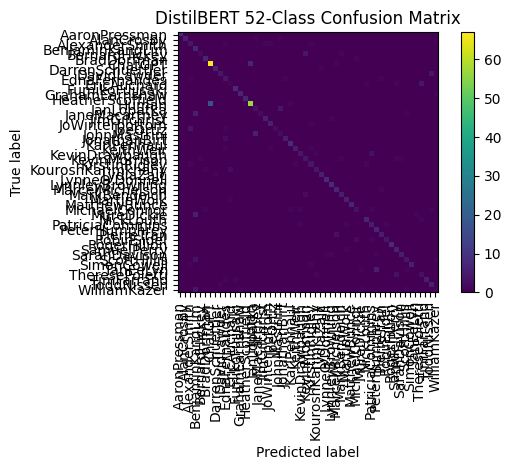

In [14]:
preds_output = trainer.predict(test_dataset)

raw_predictions = (
    preds_output.predictions[0]
    if isinstance(preds_output.predictions, tuple)
    else preds_output.predictions
)

predicted_labels = np.argmax(
    raw_predictions,
    axis=-1,
)
true_labels = preds_output.label_ids

print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=np.arange(num_classes),
        target_names=target_names,
        zero_division=0,
    )
)

plt.figure(figsize=(16, 16))
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    labels=np.arange(num_classes),
    display_labels=target_names,
    xticks_rotation=90,
    include_values=False,
)
plt.title("DistilBERT 52-Class Confusion Matrix")
plt.tight_layout()
plt.show()


### Training Curves

The original notebook contained two overlapping plotting cells. They are consolidated here.

Because Hugging Face logs training loss by logging step and evaluation metrics by epoch, the curves are shown separately instead of forcing arrays with different lengths onto the same x-axis.


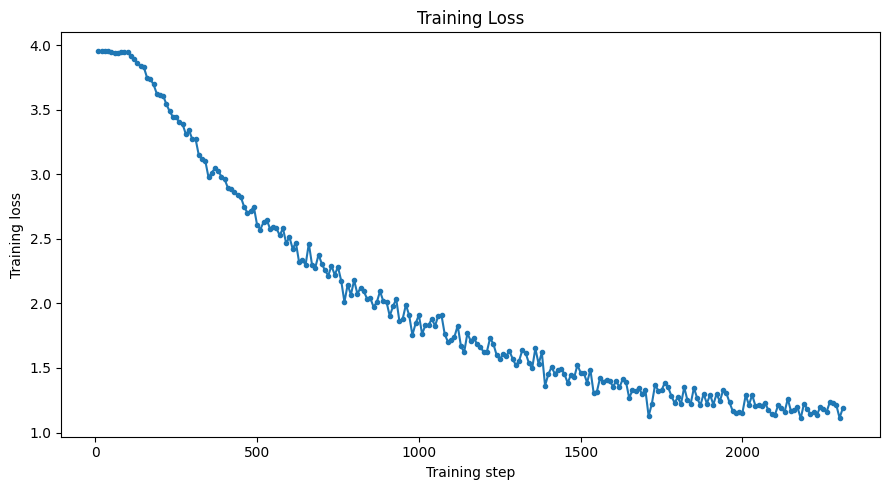

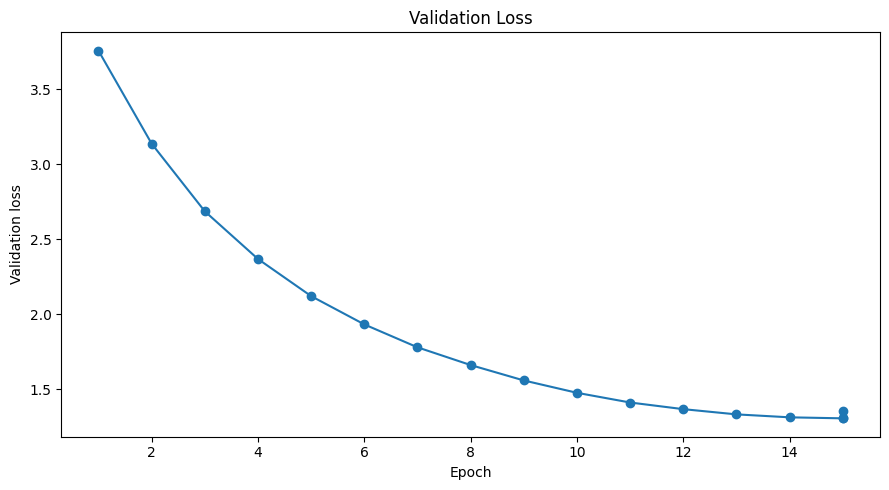

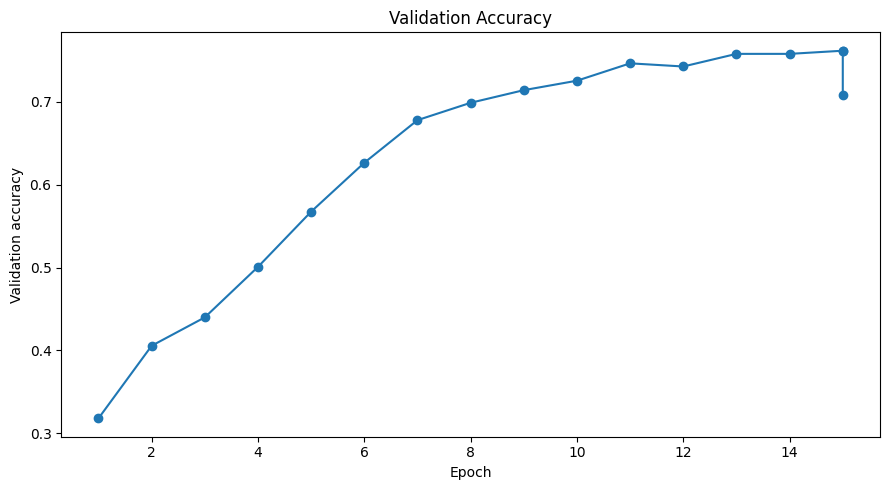

In [15]:
history = trainer.state.log_history

train_steps = [
    item["step"]
    for item in history
    if "loss" in item and "step" in item
]
train_loss = [
    item["loss"]
    for item in history
    if "loss" in item
]

eval_epochs = [
    item["epoch"]
    for item in history
    if "eval_loss" in item and "epoch" in item
]
eval_loss = [
    item["eval_loss"]
    for item in history
    if "eval_loss" in item
]
eval_accuracy = [
    item["eval_accuracy"]
    for item in history
    if "eval_accuracy" in item
]

plt.figure(figsize=(9, 5))
plt.plot(train_steps, train_loss, marker="o", markersize=3)
plt.xlabel("Training step")
plt.ylabel("Training loss")
plt.title("Training Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(eval_epochs, eval_loss, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(eval_epochs, eval_accuracy, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation Accuracy")
plt.tight_layout()
plt.show()


## 8. Statistical Analysis: Human vs ChatGPT Confidence

For samples whose true labels are Human or ChatGPT, the model probability assigned to the correct class is extracted.

A Welch independent-samples t-test is then applied to the two confidence distributions.

This test evaluates whether the **mean model confidence** differs between the two groups. A significant result should not by itself be interpreted as proof that a specific stylometric invariant caused the difference.


In [16]:
# Reuse the predictions produced above.
probabilities = torch.softmax(
    torch.tensor(raw_predictions),
    dim=-1,
).numpy()

chatgpt_index = target_names.index("ChatGPT")
human_index = target_names.index("Human")

chatgpt_scores = probabilities[
    true_labels == chatgpt_index,
    chatgpt_index,
]

human_scores = probabilities[
    true_labels == human_index,
    human_index,
]

t_stat, p_value = stats.ttest_ind(
    chatgpt_scores,
    human_scores,
    equal_var=False,
)

print("Human vs ChatGPT confidence analysis")
print(
    f"ChatGPT mean confidence: "
    f"{chatgpt_scores.mean() * 100:.2f}%"
)
print(
    f"Human mean confidence: "
    f"{human_scores.mean() * 100:.2f}%"
)
print(f"Welch t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.8f}")

if p_value < 0.05:
    print(
        "The mean confidence scores differ "
        "significantly at alpha = 0.05."
    )
else:
    print(
        "No statistically significant difference "
        "was detected at alpha = 0.05."
    )


Human vs ChatGPT confidence analysis
ChatGPT mean confidence: 53.74%
Human mean confidence: 48.12%
Welch t-statistic: 2.8328
p-value: 0.00526151
The mean confidence scores differ significantly at alpha = 0.05.


## 9. Save the Final Model

The model, tokenizer, and class-label mapping are saved together so that inference does not depend on variables remaining in notebook memory.


In [17]:
MODEL_DIR = Path("artifacts/final_model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

label_mapping = {
    str(index): author
    for index, author in enumerate(target_names)
}

with (MODEL_DIR / "label_mapping.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        label_mapping,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(f"Saved model to: {MODEL_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: artifacts/final_model


## 10. Inference on Unseen Text

This function loads the saved model and returns the top-k author classes for a new text.

The probabilities reported below are the model's original softmax probabilities. They are **not renormalized only across the top-k classes**, which makes their interpretation clearer.


In [18]:
def predict_text(
    text,
    model_dir="artifacts/final_model",
    top_k=5,
):
    model_dir = Path(model_dir)

    inference_tokenizer = AutoTokenizer.from_pretrained(
        model_dir
    )
    inference_model = (
        AutoModelForSequenceClassification
        .from_pretrained(model_dir)
        .to(device)
    )
    inference_model.eval()

    with (model_dir / "label_mapping.json").open(
        "r",
        encoding="utf-8",
    ) as file:
        mapping = json.load(file)

    inputs = inference_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        logits = inference_model(**inputs).logits

    probs = torch.softmax(logits, dim=-1)[0]

    k = min(top_k, len(mapping))
    top_probs, top_indices = torch.topk(probs, k=k)

    results = []

    for prob, index in zip(
        top_probs.cpu().tolist(),
        top_indices.cpu().tolist(),
    ):
        results.append({
            "author": mapping[str(index)],
            "probability": prob,
        })

    return pd.DataFrame(results)


example_text = """
Technology has transformed the way people communicate,
learn, and work in modern society. With the rapid
development of the internet and smart devices,
individuals can access information instantly.
"""

predict_text(example_text)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,author,probability
0,Human,0.376721
1,ChatGPT,0.340504
2,AaronPressman,0.049733
3,SamuelPerry,0.010513
4,NickLouth,0.010300


## 11. Notes for Reproducibility

This notebook intentionally removes several artifacts from the original experimentation process:

- Google Drive mounting,
- hard-coded `/content/drive/...` paths,
- `pip install` / uninstall cells,
- repeated spaCy setup,
- the unused preliminary binary-classification branch,
- duplicate training implementations,
- a later three-model benchmark that was not part of the submitted project report,
- manually typed t-test output,
- duplicate training-curve plots.

The experiment should be rerun from top to bottom before publishing the final repository. After rerunning, use the newly generated metrics in the README rather than copying values manually from the report.
